# Summer 2026 Personal Project (WIP)  
By Evan O'Malley

---

**Context**  

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
The inspiration for this project arose while reflecting on my progress as a university student. As an incoming third-year, I am well-equipped with the tools and methods of elementary data-science. However, I feel I am not backed by the relevant works.  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
To amend this, I set out to complete a data-science personal project this summer 2026 and finally staple something to my portfolio. I also figure it's worthwhile to assess and sharpen my data-science abilities as my upcoming courses will undoubtedly require my best.  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
Most importantly, I want to map the intricacies of my personal data-science techniques: my favors, my organization, my habits, and the like.  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
This project surrounds Pew Research's [Western Europe Survey Dataset](https://www.pewresearch.org/dataset/western-europe-survey-dataset/). I chose it for little more than personal intereset. What greater rationale is there for a personal project, after all.  

---

**Project Goals**  

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
It would be quite the waste if I complete this project and learn nothing from it, so below are all that I wish to exercise.  

- **Effective Use of Library Functions**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
It should be no surprise I will use a few of the essential data-science python packages. This past year, I've learnt the differences between interpreted and compiled languages, and gained insights on the importance of these packages. Hence, I will attempt to use them to their fullest here.  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
In particular, I will steer clear of instruction-intense programming in native python, avoiding `for` loops, `while` loops, homemade functions, and repetitive code unless I find no alternative. Referencing documentation for more efficient methods will be a frequent practice.

- **Producing Legible Work, as if for Presentation**  

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
I will be supplementing resumes and online profiles with this project – I would guess you may have encountered it this way – so I will focus on keeping my work tidy, as both a curtesy to the reader and a service to myself.  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
Readability to me mostly takes place as concise commenting, intuitive naming schemes, DRY principles, and ample whitespace. Another unignorable factor due to the nature of the python notebook is the structure. The notebook should flow and build upon itself, following the insticts of inspiration, aided by Markdown. It should not suggest skipping sections, visiting future sections, addressing multiple sections simultaneously, or whatever else may impair the reader's experience.  

- **Building a Coherent Environment**  

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
The tools I create for this project should be robust and comprehensive, properties to give me freedoms to manipulate and process the data. It would be as if I am making my own package for this project, and anyone could gain access and continue my work.  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
Besides the legibility conditions above, I want all objects (classes, functions, instances, etcetera) to be accessible and adaptable to whatever I may imagine. This entails a healthy serving of docstrings, error handling, data storage, case-awareness, abstraction, and file management.  

- **Git**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
I lack much Git experience at the moment, and given the intended publicity of this and future projects, I have to acclimate myself to it. This also gives the opportunity to develop healthy Git habits surrounding frequent editions and intellegent messaging.  

---

Also, no AI, as I have a head on my shoulders I like to use instead.

---

## 1 Initialization

---
### 1.1 Notebook Setup

#### 1.1.1 Imports  

&nbsp;&nbsp;&nbsp;&nbsp;
Import **Pandas**, **Numpy**, and **Matplotlib**, as well as the path to the data, a csv file of all numbers.  

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
data_rel_path = "Data/Western_Europe_Public_Data_Church_Tax_Added.csv"

&nbsp;&nbsp;&nbsp;&nbsp;
Import **Codebook**, a reference for the survery, informing us of the enumeration from the csv to the written-word responses of the survey.  
&nbsp;&nbsp;&nbsp;&nbsp;
`codebook.txt` is formatted specifically to create a dictionary-like object, as detailed in *Precursor Structures*.  
&nbsp;&nbsp;&nbsp;&nbsp;
The other codebooks in the `Codebooks` directory are for user reference. They contain much more detailed information on each question, as they are not formatted to be parsed by a program.

In [2]:
codebook_rel_path = "Codebooks/codebook.txt"

---
#### 1.1.2 `Show` Function  

&nbsp;&nbsp;&nbsp;&nbsp;
Define `Show` function to offer different display methods, since each has their virtues and drawbacks.  
&nbsp;&nbsp;&nbsp;&nbsp;
`display` displays the most information and is the most fanciful, but the images are often too large and detailed for their purpose.  
&nbsp;&nbsp;&nbsp;&nbsp;
`print` is highly functional, but unattractive.  
&nbsp;&nbsp;&nbsp;&nbsp;
`mini` is my version of a blend between these two. It uses the visual methods of `display` without being too cumbersome.

In [3]:
def Show(*obj, method = "mini"):
    """
    Function to vary display method
    method = "print", "display", "mini", or "hide"
    
    method = "print" calls print
    method = "display" callc display
    method = "mini" creates custom miniature display
    method = "hide" creates nothing

    Not case sensitive
    """

    def _mini(mini_obj):
        """Organizer for specified _mini functions, varying by type"""
        
        def _mini_series(mini_series):
            """Shows as a row"""
            
            print(f"Name: {mini_series.name}, Length: {len(mini_series)}")
            ser_str = str(pd.DataFrame(mini_series).transpose())
            ser_str = ser_str.replace(
                          mini_series.name, 
                          " " * len(mini_series.name)
                      )

            print(ser_str[:ser_str.rfind("[") - 1])
            return

        def _mini_dataframe(mini_dataframe_ref):
            """
            Cuts to show the 4x4 corners of the dataframe
            with ellipses dividers
            if applicable
            """
            
            mini_dataframe = mini_dataframe_ref.copy()
            shape = mini_dataframe.shape
            
            if mini_dataframe.shape[0] >= 8:
                to_show_top = mini_dataframe.iloc[:4]
                to_show_bottom = mini_dataframe.iloc[-4:]

                ellipsis_filler = pd.DataFrame([],
                                      columns = mini_dataframe.columns,
                                      index = ["..."]
                                  )
                ellipsis_filler.fillna("...", inplace = True)
                
                to_show = pd.concat(
                    (to_show_top,
                     ellipsis_filler,
                     to_show_bottom)
                    , axis = 0)

                mini_dataframe = to_show

            if mini_dataframe.shape[1] >= 8:
                to_show_left = mini_dataframe.iloc[:, :4]
                to_show_right = mini_dataframe.iloc[:, -4:]

                ellipsis_filler = pd.DataFrame([],
                                      columns = ["..."],
                                      index = mini_dataframe.index)
                ellipsis_filler.fillna("...", inplace = True)
                
                to_show = pd.concat(
                    (to_show_left,
                     ellipsis_filler,
                     to_show_right)
                    , axis = 1)

                mini_dataframe = to_show
                
            display(mini_dataframe)
            print(f"{shape[0]} rows x {shape[1]} cols")

        # Execution of _mini()
        show_types = {pd.Series : _mini_series,
                      pd.DataFrame : _mini_dataframe,
                     }

        if type(mini_obj) in show_types:
            show_types[type(mini_obj)](mini_obj)
        else:
            print(mini_obj)

        return
    
    # Execution of Show()
    assert method.lower() in ["mini", "print", "display", "hide"], (
        "method parameter must be:\n"+
        '"mini"\n'+
        '"print"\n'+
        '"display"\n'+
        '"hide"\n'+
        'Not case sensitive'
    )

    if method.lower() == "hide":
        return
    
    for o in obj:
        show_methods = {"print" : print,
                        "display" : display,
                        "mini" : _mini}
        
        show_methods[method.lower()](o)

    return
    

---
### 1.2 Precursor Structures

#### 1.2.1 OrderLegend  
&nbsp;&nbsp;&nbsp;&nbsp;
The **OrderLegend** class is the object that will hold most of the data in `codebook.txt`. Each instance has an **order** and a **legend** (as can be reasonably inferred).  
&nbsp;&nbsp;&nbsp;&nbsp;
The **order** attribute is one of 3 strings: `Ordinal`, `Cardinal`, or `Categorical`. 
The choices in response to an `Ordinal` question are in order, where option `1` is the "least", in some regard, but not necessarily half of option `2`. 
`Cardinal` responses are in order, like `Ordinal` responses, but magnitude holds. `Cardinal` questions are not mulitple choice. Responding `10` implies 10 less than a response of `20`. 
`Categorical` questions are multiple choice, but every choice has no relation to any other. `1` could be *Cat*, `2` *Dog*, and `3` *Hampster*. The **order** of each question was determined by me.  
&nbsp;&nbsp;&nbsp;&nbsp;
The **legend** attribute is a dictionary that corresponds the enumerated responses in the csv file to the written-word responses in the codebook.  
&nbsp;&nbsp;&nbsp;&nbsp;
**OrderLegend** objects have several methods to imitate python dictionaries, like `values`, `keys`, and `items`, as well as methods to access its attributes.  

In [4]:
class OrderLegend:
    def __init__(self, order: str, legend: dict):
        """
        Create OrderLegend object with order and legend attribute
        
        order = "Ordinal", "Cardinal", or "Categorical"
        
        Not case sensitive

        legend is a python dictionary
        """

        assert order.title() in ["Ordinal", "Cardinal", "Categorical"], (
            'order attribute must be:\n'+
            '"Ordinal"\n'+
            '"Cardinal"\n'+
            '"Categorical"\n'+
            'Not case sensitive'
        )

        self.order = order.title()
        self.legend = legend
        
    def ord(self):
        """Return order attribute (self.order)"""
        
        return self.order
    
    def leg(self):
        """Return legend attribute (self.legend)"""
        
        return self.legend
    
    def values(self):
        """Return values of self.legend"""
        
        return self.legend.values()

    def keys(self):
        """Return keys of self.legend"""
        
        return self.legend.keys()

    def items(self):
        """Return items of self.legend"""
        
        return self.legend.items()

    def len(self):
        """Returns length of self.legend"""
        
        return len(self.legend)

    def __repr__(self):
        """String representation of self"""
        
        return f"{self.order}, {self.legend}"

    def __str__(self):
        """String representation of self"""
        
        return f"{self.order}, {self.legend}"

    def __getitem__(self, i):
        """Gets item in self.legend"""
        
        return self.legend[i]

---
### 1.3 File Parsing

#### 1.3.1 `codebook.txt`  
&nbsp;&nbsp;&nbsp;&nbsp;
Makes codebook.txt into `Legends`, a dictionary of questions corresponding to OrderLegend objects.

In [5]:
with open(codebook_rel_path) as f:
    codebook = f.read()

def parse_next(terminator):
    """Reads file until the next instance of the terminator"""
    
    assert len(terminator) == 1, "Terminator must be one character"
    global s
    global codebook
    
    passage = ""
    while codebook[s] != terminator:
        passage += codebook[s]
        s += 1
    s += 1
        
    return passage

# Step variable
s = 0
Legends = {}

while s < len(codebook):
    col_legend = {}
    name = parse_next(':')
    order = parse_next('{')
    s += 1
    
    if "[COUNTRY]" in name:
        while codebook[s] != '!':
            idx = int(parse_next(' '))
            val = parse_next('\n')
            col_legend[idx] = val
        s += 1

        # I thought I needed this line at one point,
        # but I have not used it
        # Legends[name.replace("[COUNTRY]", "")] = OrderLegend(order, {})
        
        while codebook[s] != '}':
            CTY = codebook[s:s+3]
            s += 5
            
            while codebook[s] != '}':
                idx = int(parse_next(' '))
                val = parse_next('\n')
                col_legend[idx] = val
            s += 2

            col_legend[98] = "Don't know"
            col_legend[99] = "Refused"

            Legends[
                name.replace("[COUNTRY]", CTY)
            ] = OrderLegend(order, col_legend)
            
        s += 2
            
    else:
        while codebook[s] != '}':
            idx = int(parse_next(' '))
            val = parse_next('\n')
            col_legend[idx] = val
        s += 2

        col_legend[98] = "Don't know"
        col_legend[99] = "Refused"

        Legends[name] = OrderLegend(order, col_legend)

---
### 1.4 Parent Restitching  

&nbsp;&nbsp;&nbsp;&nbsp;
**Note**: All the cells in this section modify the Parent DataFrame and are not to be run out of order.

#### 1.4.1 Instantiate Parent DataFrame    
&nbsp;&nbsp;&nbsp;&nbsp;
Import the raw data into a pandas DataFrame.  

In [6]:
Parent_DF = pd.read_csv(data_rel_path,
                        skipinitialspace=True,
                        index_col = "QRID")

# Initial look at Parent_DF
# First demonstration of `Show`, where `method = "Mini"`
Show(Parent_DF, method = "Mini")

,country,weight,Q1,Q2,...,QS12SWE,QS12CHE,QS11GBR,ISCED
1006015,1,0.31258,1,2,...,NaN,NaN,NaN,5
1012247,1,2.165165,1,2,...,NaN,NaN,NaN,3
1012251,1,1.583167,1,2,...,NaN,NaN,NaN,3
1012271,1,0.705469,1,2,...,NaN,NaN,NaN,5
...,...,...,...,...,...,...,...,...,...
13646341,13,0.235802,2,1,...,NaN,NaN,NaN,3
13685713,13,0.249925,1,2,...,NaN,NaN,NaN,5
13685794,13,1.486007,2,3,...,NaN,NaN,NaN,2
13685853,13,0.43209,2,3,...,NaN,NaN,NaN,3


26096 rows x 368 cols


---
#### 1.4.2 Repair Q9 Layout  

&nbsp;&nbsp;&nbsp;&nbsp;
The layout for Q9 very peculiar, as Q9 accepted multiple responses. As it stands, Parent_DF has `1` for which of the 8 options the participant selected, as seen below.  
&nbsp;&nbsp;&nbsp;&nbsp;
98 and 99 are on every question as *Don't know* and *Refused* respectively.

In [7]:
q9_cols = Parent_DF.loc[:, 
              Parent_DF.apply(lambda x: x.name[1] == "9")
          ]

Show(q9_cols.dropna(), method = "Display")

,Q9_1,Q9_2,Q9_3,Q9_4,Q9_5,Q9_6,Q9_7,Q9_8,q9_98,q9_99
QRID,,,,,,,,,,
1012271,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1012287,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1012341,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1012360,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1012378,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
13606888,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
13606955,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13607658,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


&nbsp;&nbsp;&nbsp;&nbsp;
To fix this, I will summarize each student's response with a binary number. Each option will be represented by 1 bit. The final number will be base 10.

In [8]:
q9_binary = 2 ** np.arange(1, q9_cols.shape[1] + 1)

q9 = q9_cols.apply(
         lambda x: sum(x * q9_binary),
         axis = 1
     )

Parent_DF[q9_cols.columns[0]] = q9
Parent_DF.rename({q9_cols.columns[0] : "Q9"}, axis = 1, inplace = True)
Parent_DF.drop(q9_cols.columns[1:], axis = 1, inplace = True)

Show(Parent_DF["Q9"].dropna())

Name: Q9, Length: 5878
QRID  1012271   1012287   1012341   ...  13607658  13685794  13685853
         128.0     128.0       4.0  ...       4.0      64.0       4.0



---
#### 1.4.3 Column Cropping   

&nbsp;&nbsp;&nbsp;&nbsp;
Some variables aren't useful to me because they aren't deciphered in the codebook. The variables with prefix `QS1` are such a case. They encode regions within countries, but are unidentifialbe. Thus they will be removed, along with `qbornmoverec`.

In [9]:
QS1_cols = [i for i in Parent_DF.columns if "qs1" in i.lower()]

Parent_DF.drop(QS1_cols, axis = 1, inplace = True)
Parent_DF.drop("qbornmoverec", axis = 1, inplace = True)

---
#### 1.4.4 Column Combining  

&nbsp;&nbsp;&nbsp;&nbsp;
Other variables have identical enumeration but are separated. They were asked of different demographics, so there will be no collisions merging them.  
This goes for `QIdeology`, `QDenom`, `QChdenom`, and `QCurrel`.

**Gathering Columns**

In [10]:
# Some responses to QIdeology were on a 0-6 scale, while others where 1-7
# Here I've normalized them to 1-7
ideology_rec = Parent_DF["QIDEOLOGY"].map(
                   lambda x: x + 1 if x < 90 else x
               )
ideologya_rec = Parent_DF["QIDEOLOGYa"].map(
                    lambda x: x + 1 if x< 90 else x
                )

# QDenom had a naming convention separating the responses by country
# I have to gather them appropriately
qdenom = pd.Series([]).reindex(Parent_DF.index)
qdenom_cols = Parent_DF.loc[:,
                  Parent_DF.apply(lambda x: "qdenom" in x.name.lower())
              ]

# QChdenom had the same naming convention
qchdenom = pd.Series([]).reindex(Parent_DF.index)
qchdenom_cols = Parent_DF.loc[:, 
                    Parent_DF.apply(lambda x: "qchdenom" in x.name.lower())
                ]

# QCurrel had no such complications

In [11]:
# Before-image
qideology_cols = ["QIDEOLOGY", "QIDEOLOGYa", "QIDEOLOGYb"]
qcurrel_cols = ["QCURRELrec", "QCURRELDrec"]
Show(Parent_DF[qideology_cols],
     Parent_DF[qdenom_cols.columns],
     Parent_DF[qchdenom_cols.columns],
     Parent_DF[qcurrel_cols],
     method = "print")

          QIDEOLOGY  QIDEOLOGYa  QIDEOLOGYb
QRID                                       
1006015         2.0         NaN         NaN
1012247         4.0         NaN         NaN
1012251         2.0         NaN         NaN
1012271         4.0         NaN         NaN
1012279         1.0         NaN         NaN
...             ...         ...         ...
13646329        3.0         NaN         NaN
13646341        0.0         NaN         NaN
13685713        3.0         NaN         NaN
13685794        1.0         NaN         NaN
13685853        4.0         NaN         NaN

[26096 rows x 3 columns]
          qdenomautrec  QDENOMBEG  ...  qdenomcherec  qdenomgbrrec
QRID                               ...                            
1006015            2.0        NaN  ...           NaN           NaN
1012247            NaN        NaN  ...           NaN           NaN
1012251            NaN        NaN  ...           NaN           NaN
1012271            2.0        NaN  ...           NaN           NaN


Messy.

**Merging Columns**

In [12]:
# QIdeology
QIdeology = Parent_DF["QIDEOLOGYb"].fillna(ideology_rec).fillna(ideologya_rec)

# QDenom
qdenom_cols.apply(lambda x: qdenom.fillna(x, inplace = True))

# QChdenom
qchdenom_cols.apply(lambda x: qchdenom.fillna(x, inplace = True))

# QCurrel
QCurrel = Parent_DF["QCURRELrec"].fillna(Parent_DF["QCURRELDrec"])

**Altering Parent DataFrame: Assigning, Dropping, and Renaming Columns**

In [13]:
# QIdeology
Parent_DF["QIDEOLOGY"] = QIdeology
Parent_DF.drop(["QIDEOLOGYa", "QIDEOLOGYb"], axis = 1, inplace = True)

# QDenom
Parent_DF[qdenom_cols.columns[0]] = qdenom
Parent_DF.rename({qdenom_cols.columns[0] : "qdenom"}, axis = 1, inplace = True)
Parent_DF.drop(qdenom_cols.columns[1:], axis = 1, inplace = True)

# QChdenom
Parent_DF[qchdenom_cols.columns[0]] = qchdenom
Parent_DF.rename({qchdenom_cols.columns[0] : "qchdenom"},
                     axis = 1, inplace = True)
Parent_DF.drop(qchdenom_cols.columns[1:], axis = 1, inplace = True)

# QCurrel
Parent_DF["QCURRELrec"] = QCurrel
Parent_DF.drop("QCURRELDrec", axis = 1, inplace = True)

# After-image
Show(Parent_DF[["QIDEOLOGY", "qdenom", "qchdenom", "QCURRELrec"]],
     method = "display")

,QIDEOLOGY,qdenom,qchdenom,QCURRELrec
QRID,,,,
1006015,3.0,2.0,2.0,1
1012247,5.0,NaN,2.0,92
1012251,3.0,NaN,NaN,91
1012271,5.0,2.0,2.0,1
1012279,2.0,2.0,2.0,1
...,...,...,...,...
13646329,4.0,2.0,2.0,1
13646341,1.0,2.0,2.0,1
13685713,4.0,NaN,2.0,92


---
#### 1.4.5 Repair Naming Scheme  

&nbsp;&nbsp;&nbsp;&nbsp;
The columns in the Parent DataFrame are inconsistently named. The function below defines my choice naming scheme.

In [14]:
def title_scheme(title: str):
    # Cumulatively adjusts column titles according to scheme described below
    new_title = title

    # Remove instances of "rec", signifying recoded variables
    if new_title[-3:].lower() == "rec":
        new_title = new_title[:-3]

    # Normalize capitalization scheme
    # "country" -> "Country"
    # "QCURREL", "qcurrel" -> "QCurrel"
    if new_title[0].lower() != 'q':
        new_title = new_title.title()
    else:
        new_title = 'Q' + new_title[1:].title()
    
    # Capitalize suffixes signifying country
    # "QDenomaut" -> "QDenomAUT"
    if new_title[-3:].upper() in Legends["Country"].values():
        new_title = new_title[:-3] + new_title[-3:].upper()
        
    if new_title[-4:-1].upper() in Legends["Country"].values():
        new_title = new_title[:-4] + new_title[-4:-1].upper() + new_title[-1]

    # Some questions are divided into cases a, b, c, etcetera
    # Denotation will be separated from the main title and uncapitalized
    # "Q4A", "Q4B" -> "Q4_a", Q4_b"
    # These are dicipherable by last 2 characters of the title

    num_cap = new_title[-2].isnumeric() and new_title[-1].isupper()
    cap_uncap = new_title[-2].isupper() and new_title[-1].islower() 
    
    if num_cap or cap_uncap:
        new_title = new_title[:-1] + "_" + new_title[-1].lower()

    # Choice adjustments
    # "QPty" -> "QPtycls"
    # "QPtya" -> "QPtypotvot"
    # "QPtyb" -> "QPtyfvr"
    # Further notated in rename_key
    if new_title[:4] == "QPty":
        if new_title[4] == 'a':
            new_title = new_title[:4] + "potvot" + new_title[5:]
        elif new_title[4] == 'b':
            new_title = new_title[:4] + "fvr" + new_title[5:]
        else:
            new_title = new_title[:4] + "cls" + new_title[4:]

    rename_key = {"QCitizen1" : "QCitizen",
                  "QBornc" : "QBornmthr",
                  "QBorne" : "QBornfthr",
                  "QChilda" : "QChild",
                  "QHhch" : "QParent"}

    if new_title in rename_key.keys():
        new_title = rename_key[new_title]
    
    return new_title

Parent_DF.rename(title_scheme, axis = 1, inplace = True)

# There are 300 columns, so I will not encumber the notebook with them all
Show(Parent_DF.columns.to_numpy(), method = "Hide")

---
#### 1.4.6 Comprehensive Legend

&nbsp;&nbsp;&nbsp;&nbsp;
Currently, `Legends` has keys like `Q4_`, which decipher all `Q4_a`, `Q4_b`, and so forth. However, this entails `"Q4_a" in Legends` returns `False`, which has provent difficult. For ease of use, I will add every column into `Legends`. Note this leaves `Q4_` in `Legends` as an artifact.

In [15]:
for l in Parent_DF.columns:
    if l in Legends:
        continue
    else:
        Legends[l] = OrderLegend(Legends[l[:-1]].ord(), Legends[l[:-1]].leg())

---
#### 1.4.7 Contrain Values

&nbsp;&nbsp;&nbsp;&nbsp;
Due to some error, there are values in the Parent DataFrame that are not deciphered by the codebook. Each of these values is to be replaced by `np.nan`.

In [16]:
# This will ruin all cardinal columns and Q9
Parent_DF_tmp = Parent_DF.copy()
Parent_DF = Parent_DF.apply(
                lambda x: x.where(np.isin(
                    x, np.array(list(Legends[x.name].keys()))
            )))

# This will fix them
Parent_DF["Q9"] = Parent_DF_tmp["Q9"]
for i in Legends.keys():
    if Legends[i].ord() == "Cardinal":
        Parent_DF[i] = Parent_DF_tmp[i]

---
### 1.5 Further Preparations

#### 1.5.1 Miscellaneous Functions  
&nbsp;&nbsp;&nbsp;&nbsp;
Miscellaneous functions for table manipulations.

In [17]:
def SepOrder(df: pd.DataFrame, cardinality_arg: str, exclude = False):
    """
    Separate dataframe by cardinality
    
    cardinality_arg = "Ordinal", "Cardinal", or "Categorical"

    Not case sensitive
    
    exclude: If True, return the DataFrame whose columns are NOT that of the argument
    """

    assert cardinality_arg.title() in ["Ordinal", "Cardinal", "Categorical"], (
        'cardinality_arg must be:\n'+
        '"Ordinal"\n'+
        '"Cardinal"\n'+
        '"Categorical"\n'+
        'Not case sensitive'
    )

    # I'm really proud of this logic
    #
    #  Column order == cardinality_arg | exclude | Keep in DF?
    # ---------------------------------|---------|-------------
    #  True                            | True    | False
    #  True                            | False   | True
    #  False                           | True    | True
    #  False                           | False   | False
    #
    # This is equivalent to the xor truth table, thus
    #
    # > (Legends[x.name].ord() == cardinality_arg.title()) ^ exclude
    #
    # is the appropriate logic
    
    return df.loc[:, df.apply(lambda x: 
               (Legends[x.name].ord() == cardinality_arg.title()) ^ exclude
           )]
    
def strip_countries(title: str):
    """
    If a country in present in a column name, remove it
    "QDenomAUT" -> "QDenom"
    """
    
    if title[-3:] in Legends["Country"].values():
        return title[:-3]

    if title[-5:-2] in Legends["Country"].values():
        return title[:-5] + title[-2:]

    return title

def disambiguate(col: pd.Series):
    """If a column in enumerated, decipher the column according to Legends"""
    
    if col.dtypes != str:
        return col.dropna().map(lambda x: Legends[col.name][x])
    else:
        return col

def enumerate(col: pd.Series):
    """If a column is disambiguated, enumerate it according to Legends"""
    # FIXME this doesn't work on Q9
    
    if col.dtypes in [int, float]:
        return col
    else:
        reverse_legend = {y:x for x,y in Legends[col.name].items()}
        return col.dropna().map(lambda x: reverse_legend[x])

def Hist(data = np.array([]),
         title = None,
         xlab = None,
         ylab = "Count",
         bins = 10,
         xmin = None, xmax = None,
         ymin = None, ymax = None
        ):
    
    """Default histogram function as per my preferences"""

    fig, ax = plt.subplots()

    if title: ax.set_title(title, size = 8)
    if xlab: ax.set_xlabel(xlab, size = 6)
    if ylab: ax.set_ylabel(ylab, size = 6)
    if xmin: ax.set_xlim(xmin = xmin)
    if xmax: ax.set_xlim(xmax = xmax)
    if ymin: ax.set_ylim(ymin = ymin)
    if ymax: ax.set_ylim(ymax = ymax)

    fig.set_dpi(250)
    fig.set_size_inches(3, 2)
    ax.hist(data, bins = bins)
    ax.tick_params(labelsize = 5, size = 2)

    return (fig, ax)

---
### 1.6 Initialization Summary

Coalesce essential information into accessible datatypes  
- Legends object  
- OrderLegend class and methods
- Parent_DF is cleaned and normalized

Create DataFrame editing tools  
- SepOrder  
- Hist
- Supplementary functions

---
## 2 Exploration

---
### Statistic Invention
Start inventing some summary statistics

#### `Hist_Areas`
Paragraph

In [35]:
def Hist_Areas(dfref = pd.DataFrame):
    df = dfref.copy()
    def _responses(x):
        responses = x.value_counts()
        return responses / sum(responses)
        
    return df.apply(_responses)

In [49]:
def Compare_Hist_Areas(col: pd.Series, ref_idx = 0):
    comp_col = col.groupby(level = 0).apply(lambda x: x.to_numpy())
    ref_arr = col[comp_col.index[ref_idx]].to_numpy()
    
    return comp_col.apply(lambda x: sum(np.minimum(x, ref_arr)))

#### `Hist_Errors`  
A statisctic for how agreeable a question is

In [94]:
def Hist_Errors(col: pd.Series):
    comp_col = col.groupby(level = 0).apply(lambda x: x.to_numpy())
    

### Statistic Implementation
Paragraph

In [103]:
pd.pivot_table(GB_Nation["Q2"].reset_index(),
               index = "level_1", columns = "Country"
              )

Q2                      ...                              
Country       AUT       BEG       CHE  ...       PRT       SLO       SWE
level_1                                ...                              
1.0      0.181513  0.147773  0.244497  ...  0.036326  0.080351  0.178499
2.0      0.741737  0.688259  0.671624  ...  0.617546  0.607022  0.682218
3.0      0.052101  0.125506  0.054729  ...  0.254284  0.241053  0.105477
4.0      0.024650  0.038462  0.029149  ...  0.091844  0.071573  0.033807
5.0      0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000
6.0      0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000
7.0      0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000

[7 rows x 16 columns]

#### Parent Operations

In [37]:
# Compare response distributions across countries
Ordinal_DF = SepOrder(Parent_DF, "Ordinal")
Ordinal_DF = Ordinal_DF.loc[:, Ordinal_DF.apply(
                 lambda x: x.name == strip_countries(x.name)
             )]

Ordinal_DF["Country"] = disambiguate(Parent_DF["Country"])
Ordinal_DF.replace({98 : np.nan,
                    99 : np.nan},
                   inplace = True)

GB_Nation = Ordinal_DF.groupby("Country").apply(Hist_Areas).fillna(0)

In [41]:
Hist_Areas_DF = pd.DataFrame()
for r in range(16):
    df_r = GB_Nation.apply(Compare_Hist_Areas, ref_idx = r).iloc[r+1:]
    ref_country = GB_Nation.index.get_level_values(0).drop_duplicates()[r]
    df_r.index = pd.MultiIndex.from_arrays(
                     np.stack((
                         np.array([ref_country] * (15-r)), 
                         df_r.index.to_numpy()
                 )))

    Hist_Areas_DF = pd.concat((Hist_Areas_DF, df_r))

HA_Comparisons = np.ravel(Hist_Areas_DF)
per = 5
unlike_lim = np.percentile(HA_Comparisons, per)
alike_lim = np.percentile(HA_Comparisons, 100 - per)

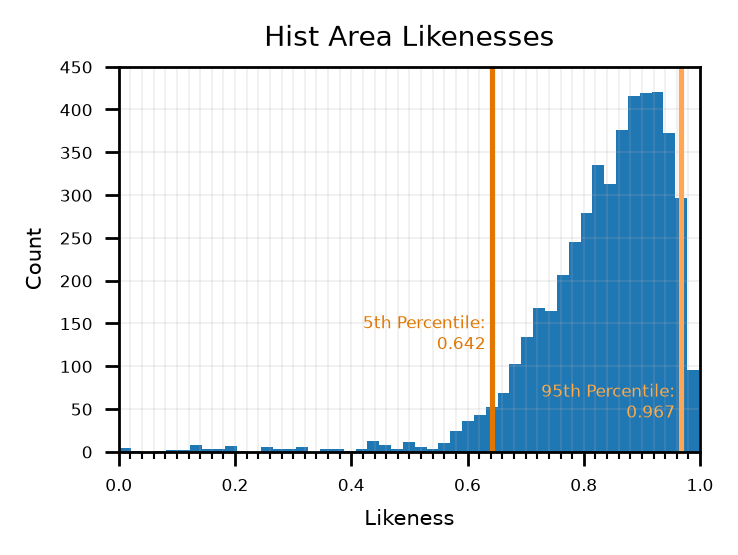

In [42]:
HAfig, HAax = Hist(data = HA_Comparisons,
                   title = "Hist Area Likenesses",
                   xlab = "Likeness",
                   bins = 49,
                   xmin = 0,
                   xmax = 1,
                   ymin = 0,
                   ymax = 450
                  )

HAax.set_xticks(minor = False, ticks = np.arange(0, 6/5, 1/5))
HAax.set_xticks(minor = True, ticks = np.arange(0, 1, 1/50))
HAax.grid(axis = 'x', which = "both", linewidth = 0.1)
HAax.tick_params(which = "minor", labelsize = 5, size = 2)
HAax.tick_params(which = "major", labelsize = 5, size = 4)
HAax.grid(axis = 'y', which = "major", linewidth = 0.1)

HAax.axvline(unlike_lim, color = "xkcd:pumpkin")
HAax.text(unlike_lim - 0.01, 120,
         f"{per}th Percentile:\n{np.round(unlike_lim, 3)}",
         ha = "right", color = "xkcd:pumpkin", size = 5
        )

HAax.axvline(alike_lim, color = "xkcd:pale orange")
HAax.text(alike_lim - 0.01, 40,
         f"{100 - per}th Percentile:\n{np.round(alike_lim, 3)}",
         ha = "right", color = "xkcd:light orange", size = 5
        )

pass # No need to see the MatPlot object

#### Attempting to bootstrap

In [43]:
HA_unlike_lims = np.array([])
HA_means = np.array([])
for h in np.arange(5e3):
    HA_rs = np.random.choice(HA_Comparisons, 
                      size = len(HA_Comparisons), replace = True
                  )
    HA_rs_unlike_lim = np.percentile(HA_rs, per)
    HA_unlike_lims = np.append(HA_unlike_lims, HA_rs_unlike_lim)
    HA_rs_mean = np.mean(HA_rs)
    HA_means = np.append(HA_means, HA_rs_mean)

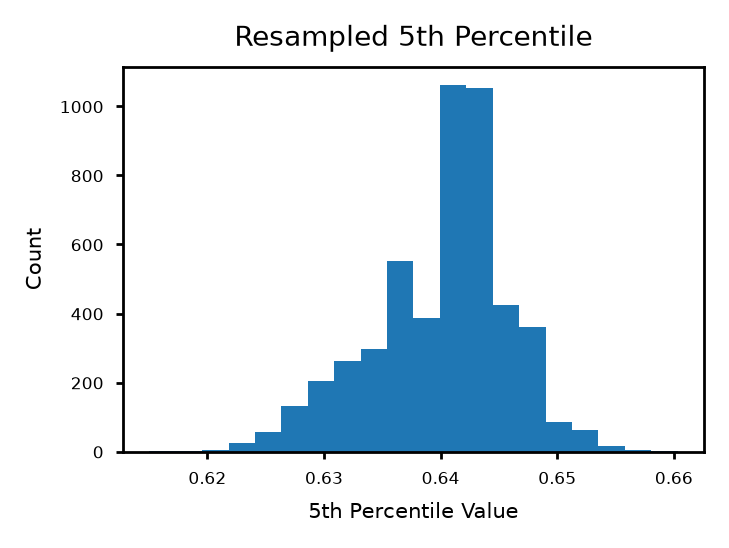

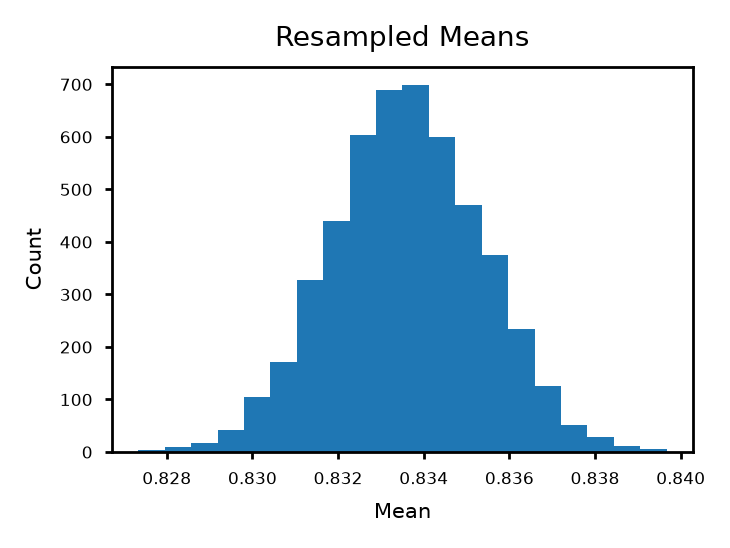

In [44]:
Hist(
    data = HA_unlike_lims,
    title = f"Resampled {per}th Percentile",
    xlab = f"{per}th Percentile Value",
    bins = 20,
)

Hist(
    data = HA_means,
    title = "Resampled Means",
    xlab = "Mean",
    bins = 20
)
pass

__Discovery:__  
Quantiles don't follow the central limit theorem.  
This makes sense, becasue other stats like the maximum don't follow it either.  
I would geuss this is because quantiles, as well as maxima/minima, aren't stats that are influenced by every data point, unlike the mean.

### Statistic Implications  
Paragraph

In [48]:
GB_Nation

Q2        Q5        Q6  ...       Q50  QIdeology     Isced
Country                                    ...                               
AUT     1.0  0.181513  0.155807  0.176471  ...  0.097126   0.010995  0.000000
        2.0  0.741737  0.651558  0.634615  ...  0.401724   0.092593  0.070225
        3.0  0.052101  0.123513  0.131222  ...  0.229885   0.311921  0.647191
        4.0  0.024650  0.069122  0.057692  ...  0.271264   0.368634  0.000000
        5.0  0.000000  0.000000  0.000000  ...  0.000000   0.134259  0.282584
...               ...       ...       ...  ...       ...        ...       ...
SWE     3.0  0.105477  0.047786  0.022712  ...  0.161538   0.144813  0.417232
        4.0  0.033807  0.024596  0.013076  ...  0.605594   0.402017  0.000000
        5.0  0.000000  0.000000  0.000000  ...  0.000000   0.258646  0.487788
        6.0  0.000000  0.000000  0.000000  ...  0.000000   0.090778  0.000000
        7.0  0.000000  0.000000  0.000000  ...  0.000000   0.030259  0.000000

[112 rows x 39 columns]

In [25]:
variability = Hist_Areas_DF.apply(np.var)
variability.sort_values()

Q20_h        0.002034
Q49_d        0.003104
Q33          0.003109
Q20_g        0.003192
Q43          0.003958
Q20_f        0.004140
Q20_b        0.004312
Q42_b        0.004742
Q16          0.005011
Q15_a        0.005232
Q47          0.005246
Q20_c        0.006007
Q48_a        0.006106
Q48_c        0.006389
Q20_e        0.006427
Q10_a        0.006487
Q48_b        0.006491
Q2           0.006680
Q42_d        0.007440
Q32_a        0.007619
Q20_d        0.007681
Q49_c        0.007888
Q10_b        0.007976
QIdeology    0.008269
Q10_c        0.008436
Q42_c        0.008438
Q24          0.008441
Isced        0.008944
Q42_a        0.010372
Q50          0.010760
Q49_a        0.011232
Q49_e        0.011347
Q20_a        0.011676
Q5           0.012271
Q49_b        0.013340
Q27          0.013855
Q6           0.016893
Q32_b        0.052752
Q15_b        0.060843
dtype: float64

In [46]:
# More Summarizing
# May delete later
Hist_Areas_PV = Hist_Areas_DF.reset_index().melt(
                    id_vars = ["level_0", "level_1"]
                )

Hist_Areas_PV.rename({"level_0" : "Country A",
                      "level_1" : "Country B"},
                     axis = 1, inplace = True)

pd.pivot_table(Hist_Areas_PV, 
               aggfunc = lambda x: (np.sum(x > alike_lim),
                                    np.sum(x < unlike_lim)),
               index = "Country A", columns = "Country B", values = "value",
               )

Country B,BEG,CHE,DEU,DNK,ESP,FIN,FRA,GBR,IRL,ITA,NLD,NOR,PRT,SLO,SWE
Country A,,,,,,,,,,,,,,,
AUT,"(0, 1)","(14, 0)","(16, 0)","(2, 2)","(0, 2)","(0, 3)","(6, 0)","(9, 0)","(6, 0)","(4, 1)","(0, 0)","(0, 1)","(0, 2)","(1, 6)","(1, 3)"
BEG,NaN,"(0, 2)","(1, 2)","(5, 0)","(1, 0)","(1, 3)","(2, 2)","(0, 2)","(1, 1)","(0, 1)","(2, 0)","(0, 0)","(2, 4)","(1, 3)","(1, 3)"
CHE,NaN,NaN,"(13, 0)","(3, 2)","(0, 2)","(0, 3)","(3, 0)","(8, 1)","(9, 0)","(3, 1)","(0, 1)","(0, 4)","(0, 2)","(0, 6)","(1, 5)"
DEU,NaN,NaN,NaN,"(0, 2)","(1, 2)","(1, 2)","(6, 0)","(10, 0)","(2, 0)","(4, 1)","(0, 0)","(1, 1)","(0, 3)","(0, 6)","(0, 1)"
DNK,NaN,NaN,NaN,NaN,"(2, 1)","(3, 2)","(0, 0)","(1, 3)","(2, 1)","(0, 2)","(0, 0)","(1, 0)","(0, 6)","(3, 3)","(1, 0)"
ESP,NaN,NaN,NaN,NaN,NaN,"(1, 3)","(2, 2)","(0, 3)","(0, 1)","(0, 0)","(0, 1)","(0, 3)","(0, 1)","(4, 3)","(0, 4)"
FIN,NaN,NaN,NaN,NaN,NaN,NaN,"(1, 2)","(1, 2)","(1, 2)","(0, 2)","(1, 3)","(1, 3)","(0, 2)","(1, 3)","(0, 4)"
FRA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(13, 0)","(5, 0)","(4, 0)","(2, 0)","(0, 0)","(0, 2)","(1, 6)","(0, 2)"
GBR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(5, 0)","(4, 1)","(2, 1)","(1, 1)","(0, 3)","(1, 7)","(0, 4)"


## Reflection
Project Reflection

**So Far:**  
- I'm glad to have made a discovery
- How much of the learning process should I have retained? Inspirations? Dead ends? Iterations? Errors!?
- I have a hunch my Hist_Areas statistic is highly biased because of the nature of permutive comparision
- Error handling in functions is slow and unnecessary because I have complete control over the environment